# CelerisAi Web-Config Tutorial

This notebook reproduces the `setrun_web.py` workflow using CelerisWEBGPU-compatible case folders.

What you will do:
- Read topography/config from a case folder
- Build domain and boundary conditions in `celeris=True` mode
- Run a 2D simulation with live display

## Prerequisites
If you have not installed CelerisAi yet, you can do it just with:

From repository root:
```bash
pip install -e .
```

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

repo_root

PosixPath('/home/wrenteria/Documents/Github_Projects/CelerisAi')

## 1) Imports and backend

In [2]:
import taichi as ti

from celeris.domain import Topodata, BoundaryConditions, Domain
from celeris.solver import Solver
from celeris.runner import Evolve

ti.init(arch=ti.gpu)

[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.10.12


[I 02/13/26 14:35:05.694 37528] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] Starting on arch=cuda


## 2) Select a case folder

Expected case files include `config.json`, `bathy.txt`, and usually `waves.txt`.

In [3]:
EXAMPLES_DIR = repo_root / 'examples'
CASE = 'Balboa'
CASE_PATH = EXAMPLES_DIR / CASE

CASE_PATH

PosixPath('/home/wrenteria/Documents/Github_Projects/CelerisAi/examples/Balboa')

## 3) Build model inputs

- `Topodata(datatype='celeris')` reads CelerisWebGPU-style bathymetry
- `BoundaryConditions(celeris=True)` reads `config.json` in the case folder

In [4]:
precision = ti.f32

baty = Topodata(datatype='celeris', path=str(CASE_PATH))
bc = BoundaryConditions(celeris=True, path=str(CASE_PATH), precision=precision)
d = Domain(topodata=baty, precision=precision)

d.Nx, d.Ny

(1067, 534)

## 4) Configure and run solver

In [6]:
solver = Solver(domain=d, boundary_conditions=bc, model='Bouss')

run = Evolve(
    solver=solver,
    maxsteps=3000,
    saveimg=True,
    plot_interval=100
)
# Interactive 2D display
#run.Evolve_Display(variable='h', cmapWater='Blues')

# Headless alternative:
run.Evolve_Headless()

Model:  Bouss
Numerical Scheme:  2  dx: 1.5  dy: 1.5
Breaking Model:  True  Sediment Transport:  False
Time delta:  0.02632219118079432
Current Simulation time: 0.00s at step: 0-- Ratio:0.00--CompTime:2.54
Current Simulation time: 0.03s at step: 1-- Ratio:2567.52--CompTime:0.00
Current Simulation time: 2.63s at step: 100-- Ratio:2.34--CompTime:1.12
Current Simulation time: 5.26s at step: 200-- Ratio:2.24--CompTime:2.35
Current Simulation time: 7.90s at step: 300-- Ratio:2.21--CompTime:3.58
Current Simulation time: 10.53s at step: 400-- Ratio:2.20--CompTime:4.80
Current Simulation time: 13.16s at step: 500-- Ratio:2.19--CompTime:6.02
Current Simulation time: 15.79s at step: 600-- Ratio:2.18--CompTime:7.25
Current Simulation time: 18.43s at step: 700-- Ratio:2.17--CompTime:8.48
Current Simulation time: 21.06s at step: 800-- Ratio:2.17--CompTime:9.70
Current Simulation time: 23.69s at step: 900-- Ratio:2.17--CompTime:10.93
Current Simulation time: 26.32s at step: 1000-- Ratio:2.16--CompTi

## Notes

- Change `CASE` to run another folder under `examples/` (for example `Ventura` or `CrescentCity`).
- Use `saveimg=False` for lighter runs.
- For CPU execution, switch to `ti.init(arch=ti.cpu)`.

## 5 Plot the results (last step)
This process can be done in any step of the numerical simulation

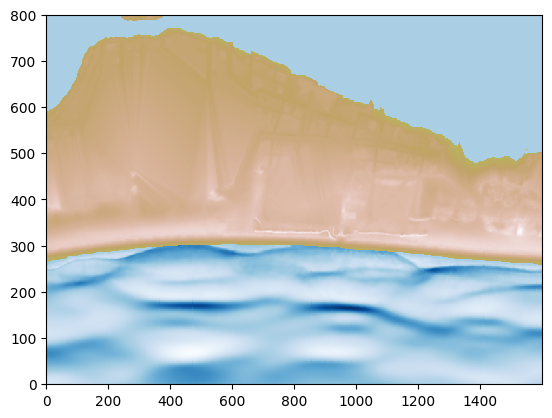

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# extract the coordinates
x_coord,y_coord,zz =solver.domain.grid()
# Hide eta where zz <= 0 (dry land)
mask = zz <= 0 

#Send data to numpy
q = run.solver.State.to_numpy()
eta_ = q[:,:,0]
hu = q[:,:,1]
# Apply the mask to water data
eta_masked = np.ma.masked_where(mask, eta)
hu_masked = np.ma.masked_where(mask, hu)
# Plot
plt.pcolor(x_coord.T,y_coord.T,eta_masked,cmap='Blues',zorder=1)
#plt.pcolor(x_coord.T,y_coord.T,hu_masked,cmap='jet',zorder=1)
plt.pcolor(x_coord.T,y_coord.T,-zz,cmap='gist_earth',zorder=0)# make bathymetry negative
